# 3.1

In [80]:
# Load and preprocess dataset
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import QuantileTransformer
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

train_df = pd.read_csv('train_data.csv')
X_raw = train_df.drop(columns=['Index', 'Bankrupt?'])
index = train_df['Index']
y = train_df['Bankrupt?']

# Remove constants and highly correlated features
X_no_constants = X_raw.loc[:, X_raw.nunique() > 1]
corr_matrix = X_no_constants.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.6)]
X_reduced_corr = X_no_constants.drop(columns=to_drop_corr)

In [81]:
X_reduced_corr[' Liability-Assets Flag'].unique()

array([0, 1])

In [82]:
for flag in [0, 1]:
    subset = X_reduced_corr[X_reduced_corr[' Liability-Assets Flag'] == flag]
    total = len(subset)
    print(f"Flag = {flag}: Total = {total}")

Flag = 0: Total = 5800
Flag = 1: Total = 7


Liability-Assets Flag should be dropped because it only has 7 samples where it equals 1, and 5800 where its 0. This imbalance might lead to overfitting, or cause the model to learn misleading patterns from a statistically insignificant group.

In [83]:
X_reduced_corr = X_reduced_corr.drop(' Liability-Assets Flag', axis=1)
X_reduced_corr

,ROA(C) before interest and depreciation before interest,Operating Gross Margin,Operating Profit Rate,Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Cash Flow Per Share,...,Current Asset Turnover Rate,Quick Asset Turnover Rate,Cash Turnover Rate,Fixed Assets to Assets,Cash Flow to Total Assets,Cash Flow to Equity,Total assets to GNP price,No-credit Interval,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT)
0,0.450397,0.594640,0.998906,8.010000e+09,0.000000e+00,0.462634,0.000414,0.000000,0.178754,0.318455,...,6.500000e+09,3.880000e+09,5.450000e+09,0.457497,0.666103,0.318116,0.004919,0.623634,0.026788,0.565144
1,0.530005,0.605695,0.999058,1.024540e-04,2.720000e+08,0.464667,0.000140,0.259439,0.200413,0.324503,...,1.481000e-04,1.199480e-04,4.450000e+09,0.265440,0.654556,0.316348,0.005968,0.624171,0.026801,0.565205
2,0.571150,0.612275,0.999163,1.059230e-04,4.240000e+09,0.472701,0.000260,0.104464,0.203278,0.332708,...,1.791900e-04,1.572580e-04,1.345160e-04,0.276147,0.691773,0.321974,0.006022,0.625306,0.026816,0.565276
3,0.483401,0.602445,0.999035,7.530000e+09,0.000000e+00,0.452369,0.000268,0.000000,0.179217,0.259638,...,4.030940e-04,2.660000e+09,6.160000e+09,0.057978,0.654096,0.318516,0.002177,0.621610,0.027063,0.566190
4,0.510359,0.600023,0.999009,6.270000e+09,2.360000e+09,0.462168,0.000409,0.732058,0.194766,0.319445,...,7.010000e+09,7.560000e+09,9.810000e+08,0.065429,0.618000,0.310454,0.001124,0.623993,0.026880,0.565549
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5802,0.507483,0.596448,0.998991,2.380000e+09,1.190000e+08,0.463560,0.000450,0.017917,0.177194,0.325387,...,5.460000e+08,3.380000e+09,1.080000e+09,0.600285,0.642195,0.314381,0.003993,0.625135,0.028366,0.568173
5803,0.553795,0.648323,0.999388,4.582670e-04,4.298970e-04,0.470282,0.000237,0.076222,0.185159,0.327014,...,3.254380e-04,2.855670e-04,6.689470e-04,0.403386,0.692402,0.320786,0.000778,0.623890,0.026821,0.565297
5804,0.491639,0.597003,0.998981,4.230000e+09,7.130000e+08,0.464598,0.000500,0.143942,0.193123,0.326378,...,5.410000e+09,3.360000e+09,2.480000e+09,0.046060,0.650947,0.315947,0.004849,0.623857,0.026902,0.565636
5805,0.513626,0.646665,0.999066,7.540660e-04,0.000000e+00,0.478879,0.000317,0.251645,0.176478,0.336670,...,1.726980e-04,1.724680e-04,3.273710e-04,0.026626,0.793044,0.355667,0.000476,0.623845,0.026791,0.565159


In [84]:
# Select top 15 features
selector = SelectKBest(score_func=f_classif, k=15)
X_selected = selector.fit_transform(X_reduced_corr, y)
selected_features = X_reduced_corr.columns[selector.get_support()].tolist()
X_selected_df = pd.DataFrame(X_selected, columns=selected_features)
X_selected_df['Bankrupt?'] = y.values

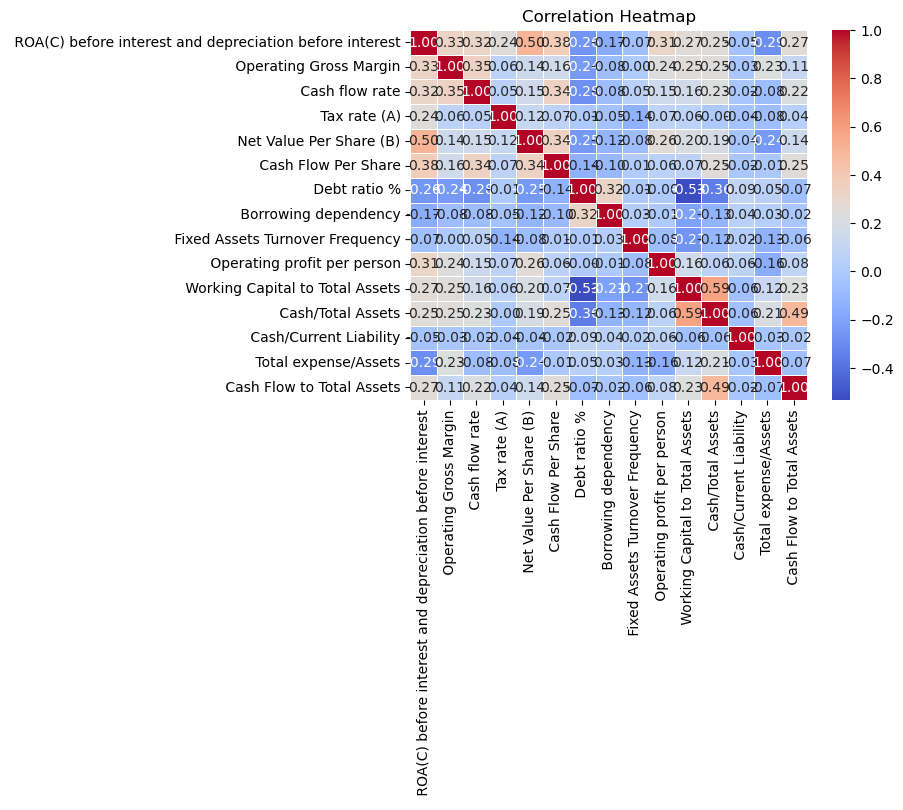

In [85]:
corr = X_selected_df.drop('Bankrupt?', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

In [86]:
print(list(X_selected_df.columns.str.strip()))

['ROA(C) before interest and depreciation before interest', 'Operating Gross Margin', 'Cash flow rate', 'Tax rate (A)', 'Net Value Per Share (B)', 'Cash Flow Per Share', 'Debt ratio %', 'Borrowing dependency', 'Fixed Assets Turnover Frequency', 'Operating profit per person', 'Working Capital to Total Assets', 'Cash/Total Assets', 'Cash/Current Liability', 'Total expense/Assets', 'Cash Flow to Total Assets', 'Bankrupt?']


## Visualizations

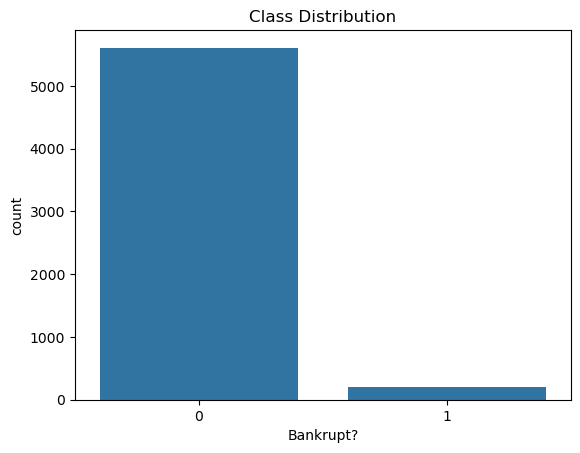

In [87]:
# Bankruptcy Distribution
sns.countplot(x='Bankrupt?', data=X_selected_df)
plt.title('Class Distribution')
plt.show()

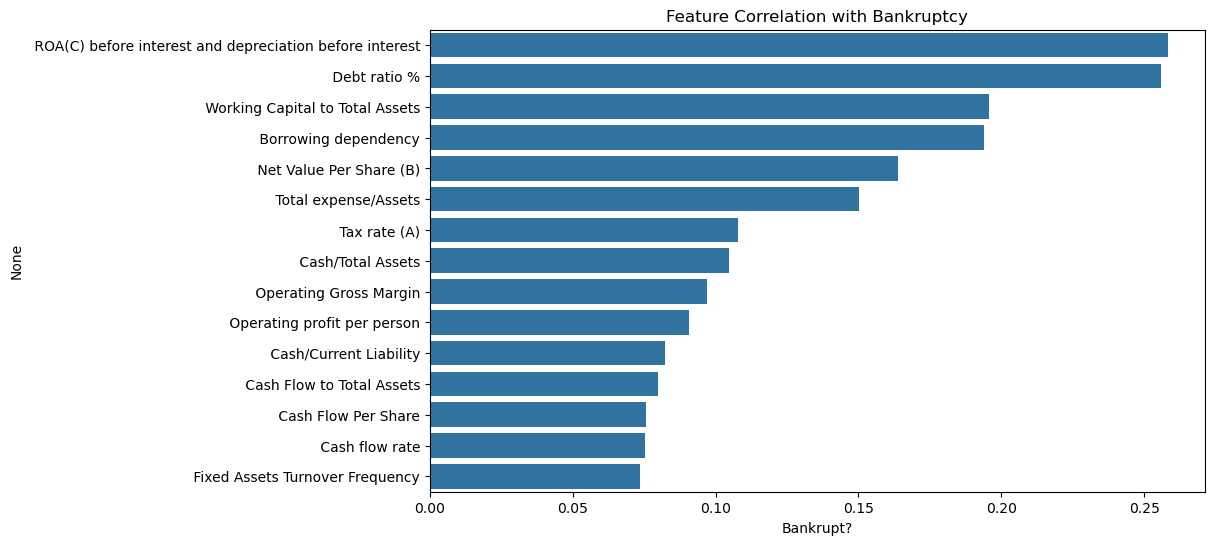

In [88]:
# Correlation with Target
corr = X_selected_df.corr()['Bankrupt?'].drop('Bankrupt?')
plt.figure(figsize=(10, 6))
sns.barplot(x=corr.abs().sort_values(ascending=False), y=corr.abs().sort_values(ascending=False).index)
plt.title('Feature Correlation with Bankruptcy')
plt.show()

## Clustering and Cluster Classifier

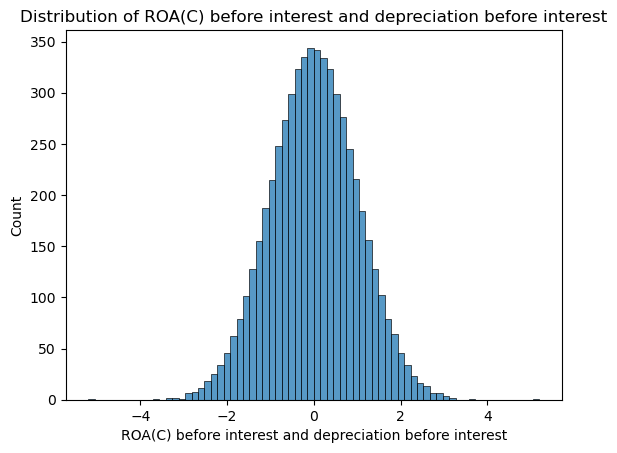

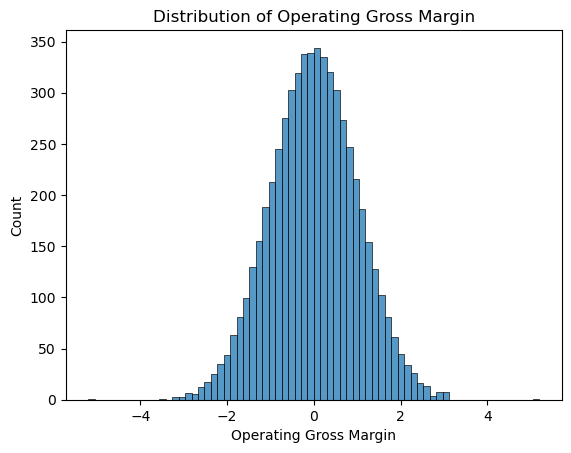

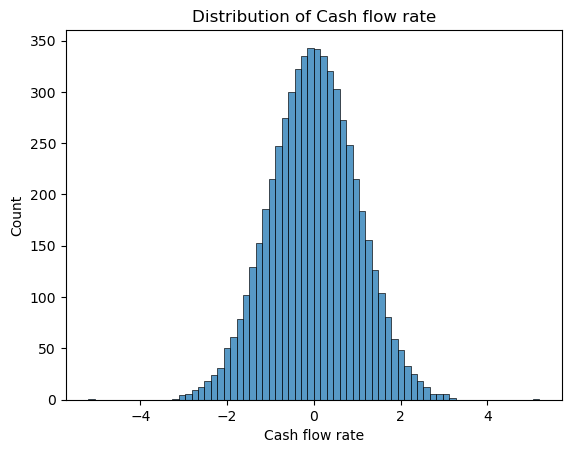

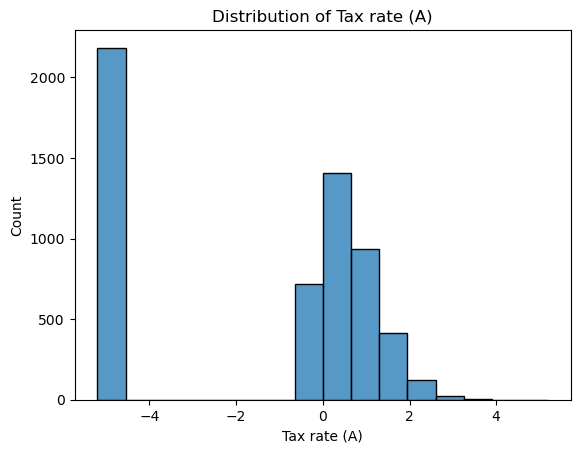

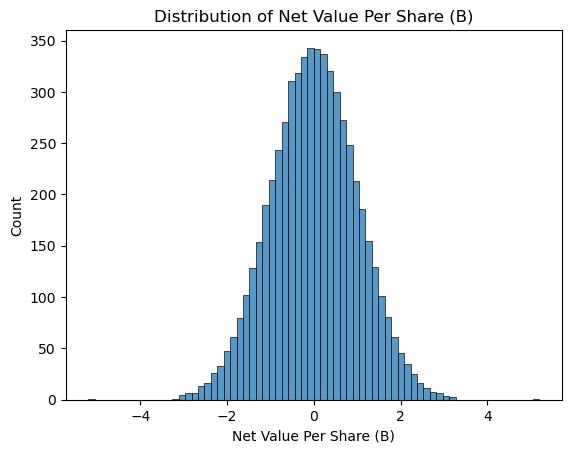

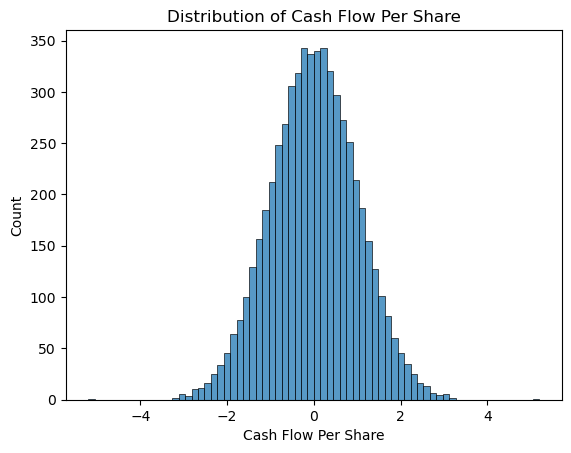

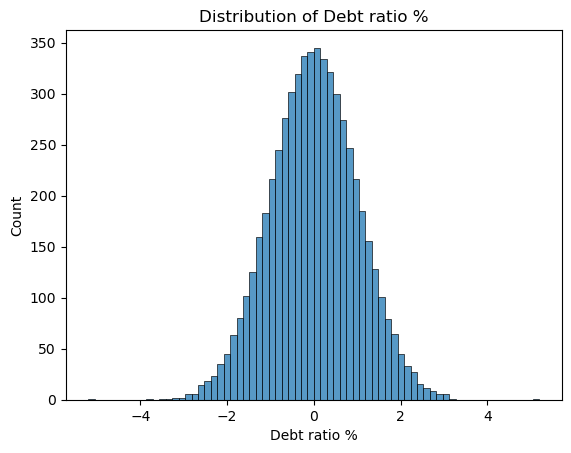

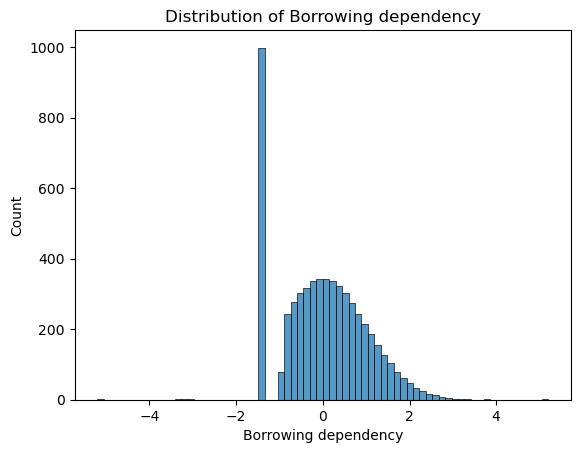

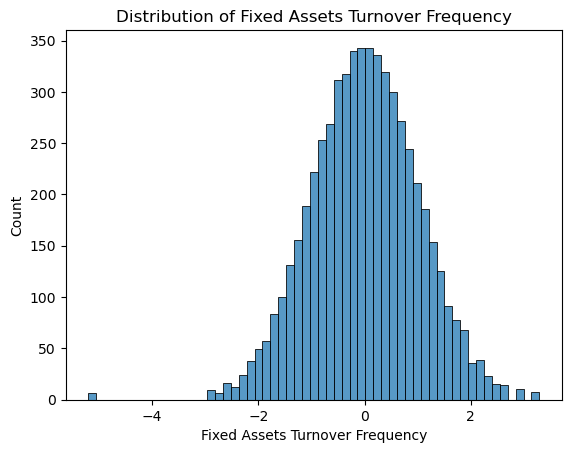

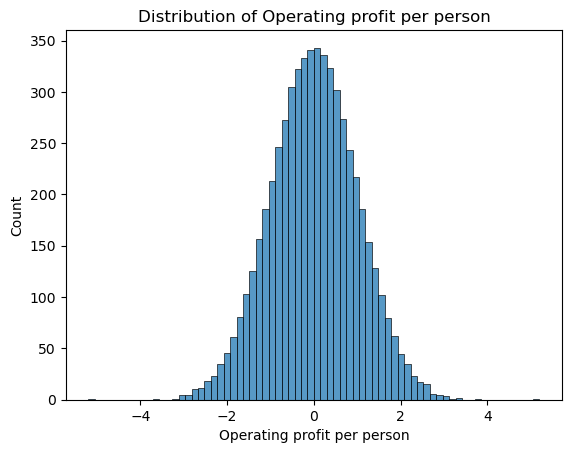

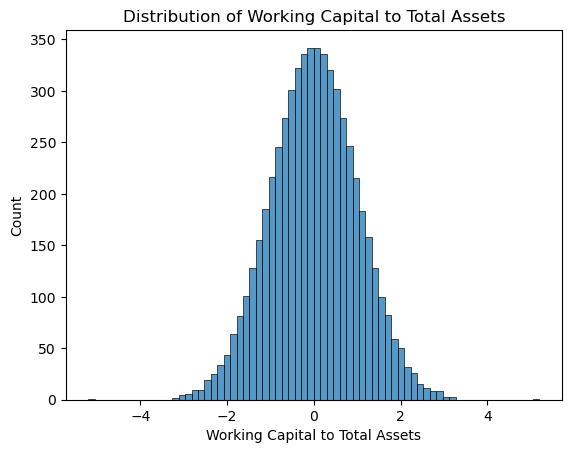

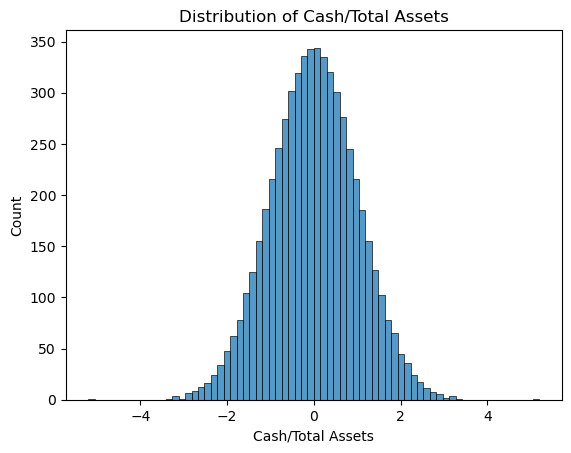

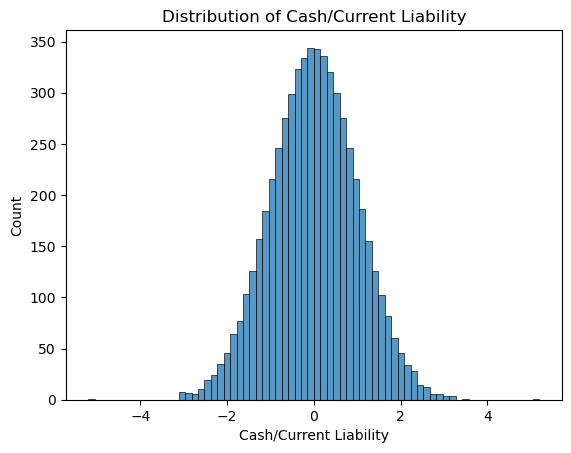

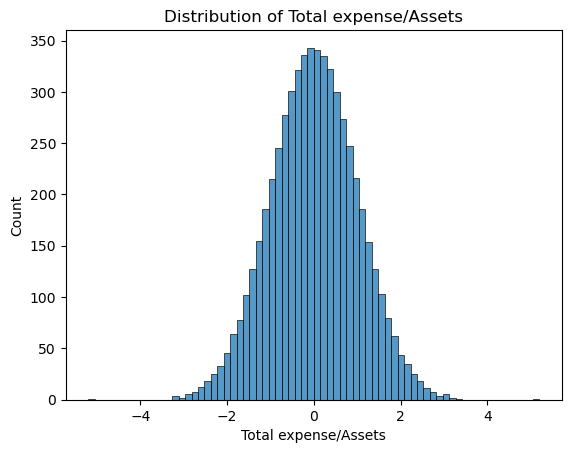

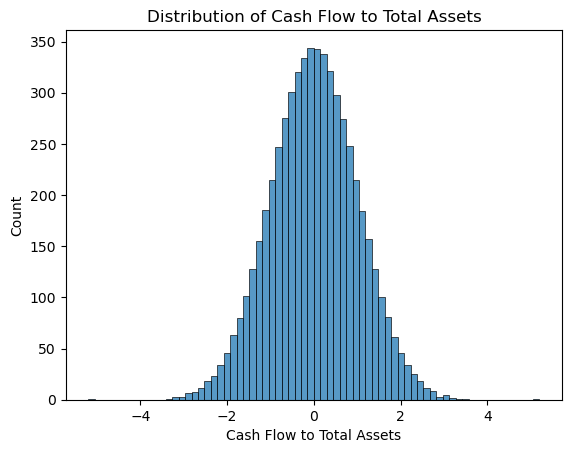

In [89]:
# Gaussian transformation for clustering
qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_norm = qt.fit_transform(X_selected_df.drop(columns=['Bankrupt?']))
X_norm_df = pd.DataFrame(X_norm, columns=selected_features)
X_norm_df.columns = X_norm_df.columns.str.strip()

for col in X_norm_df.columns:
    plt.figure()
    sns.histplot(X_norm_df[col])
    plt.title(f'Distribution of {col}')
    plt.show()

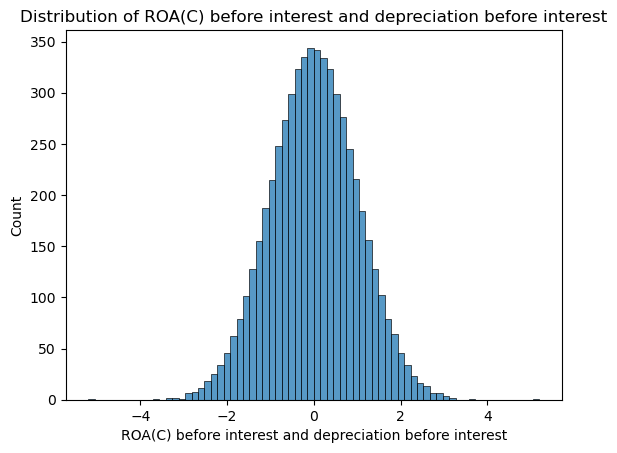

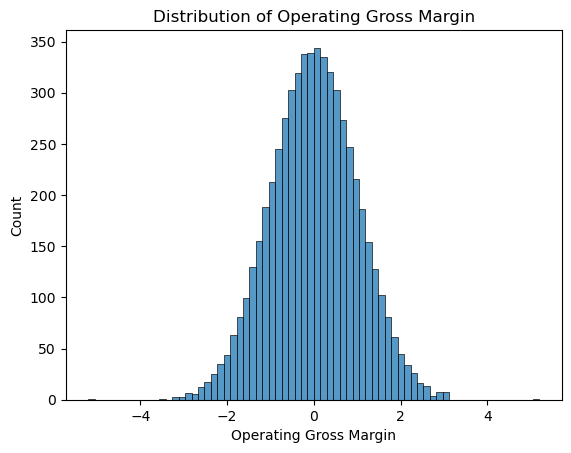

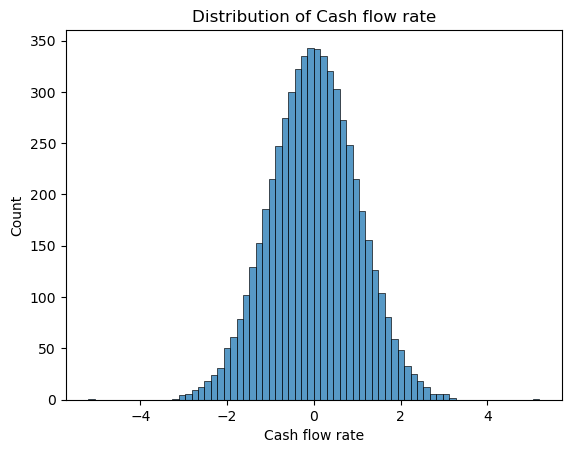

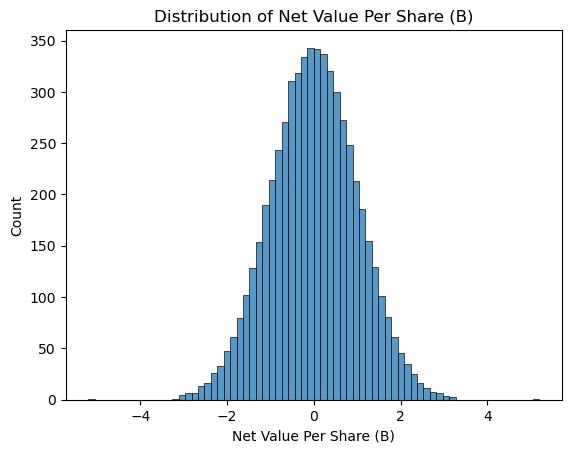

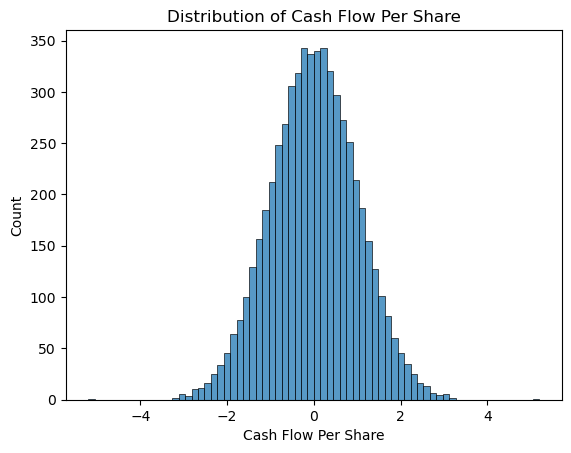

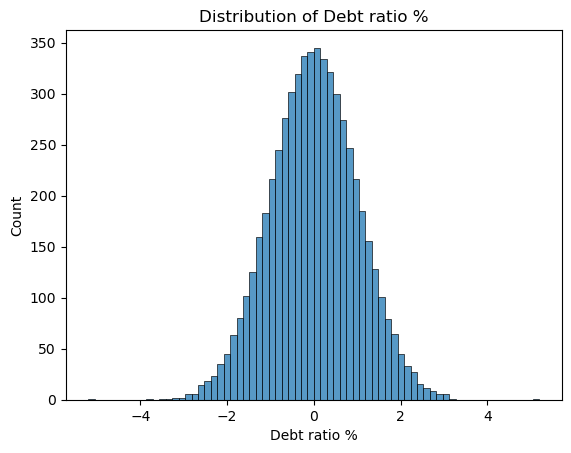

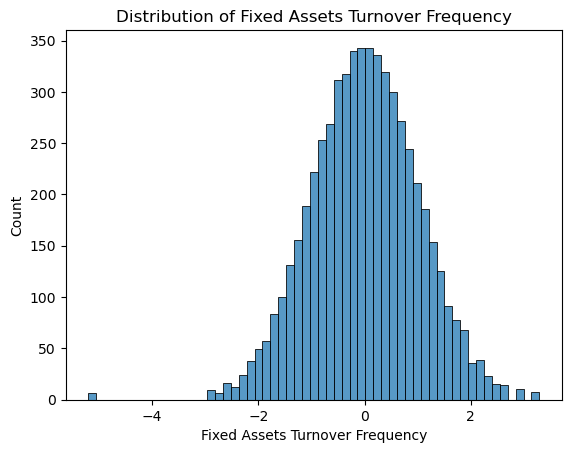

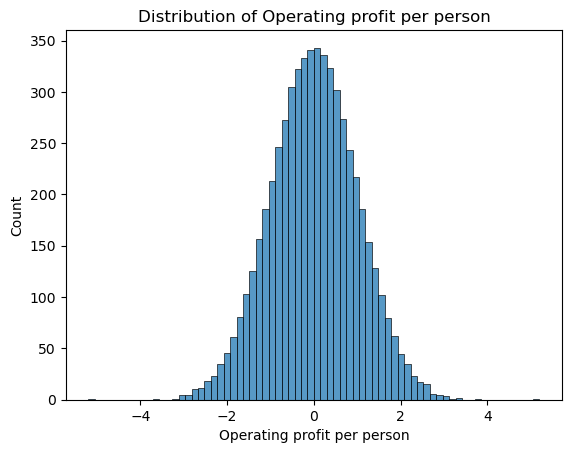

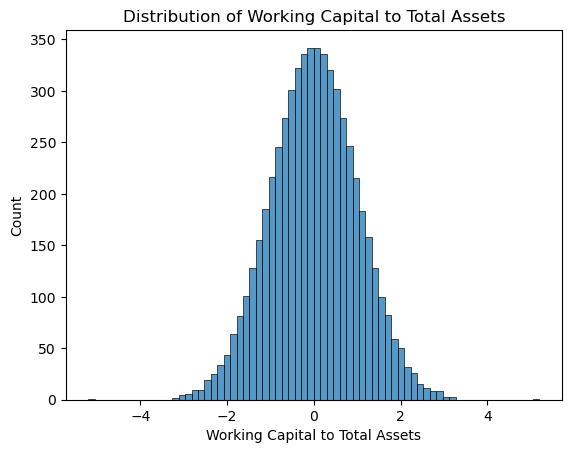

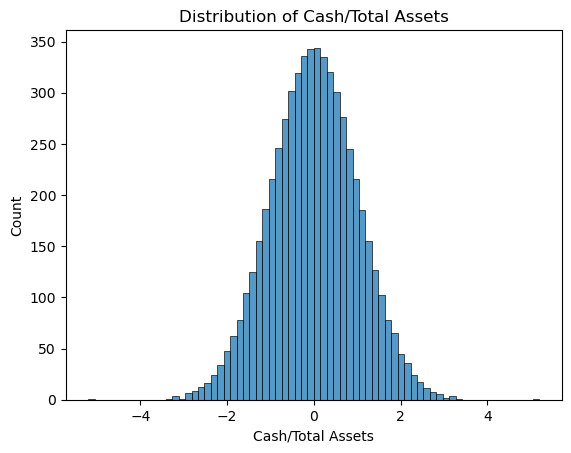

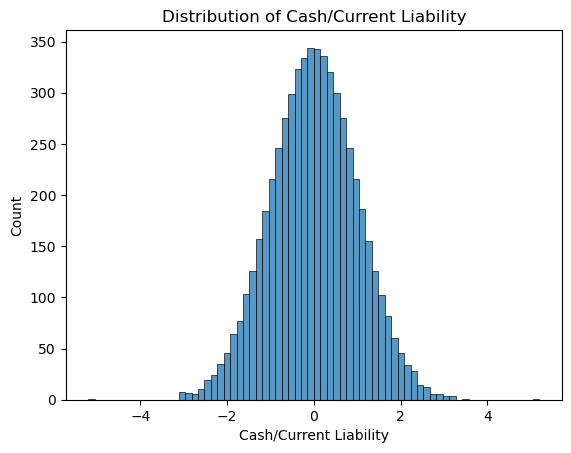

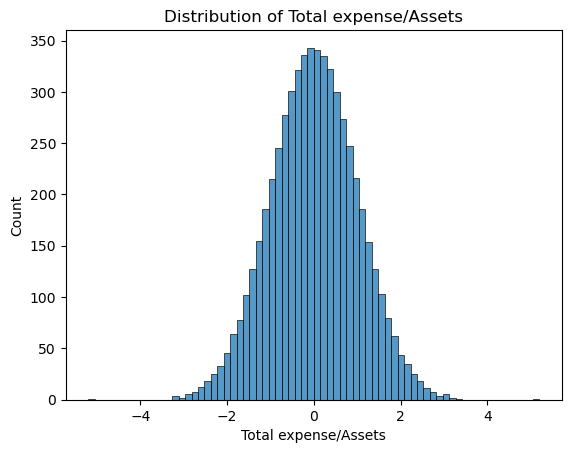

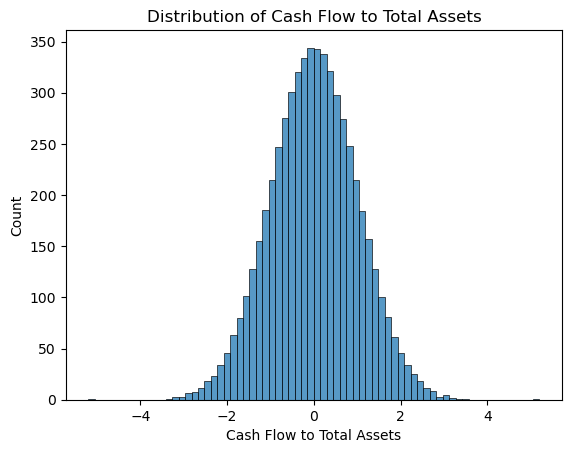

In [90]:
to_drop = ['Tax rate (A)', 'Borrowing dependency']
X_norm_df = X_norm_df.drop(to_drop, axis=1)
for col in X_norm_df.columns:
    plt.figure()
    sns.histplot(X_norm_df[col])
    plt.title(f'Distribution of {col}')
    plt.show()

In [91]:
import pickle

print(list(X_norm_df.columns))

cluster_features = list(X_norm_df.columns)

with open('cluster_features.pkl', 'wb') as f:
    pickle.dump(cluster_features, f)



['ROA(C) before interest and depreciation before interest', 'Operating Gross Margin', 'Cash flow rate', 'Net Value Per Share (B)', 'Cash Flow Per Share', 'Debt ratio %', 'Fixed Assets Turnover Frequency', 'Operating profit per person', 'Working Capital to Total Assets', 'Cash/Total Assets', 'Cash/Current Liability', 'Total expense/Assets', 'Cash Flow to Total Assets']


# 3.2

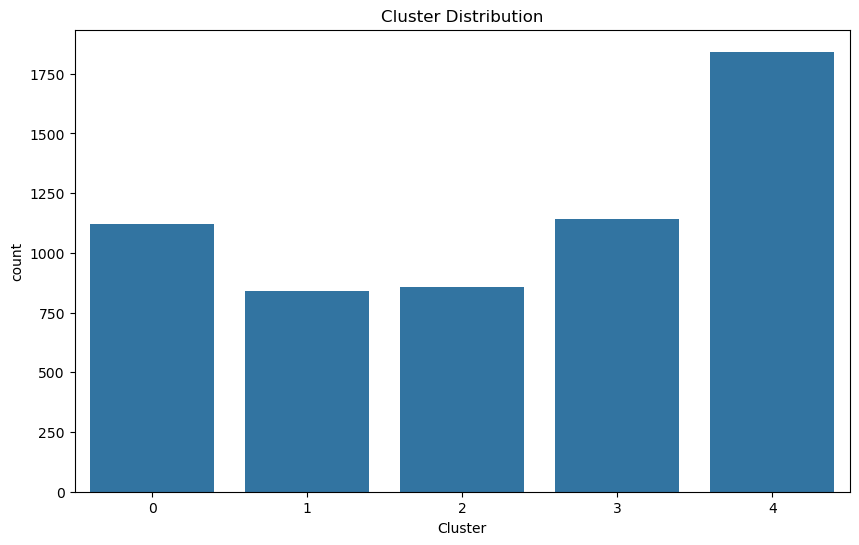

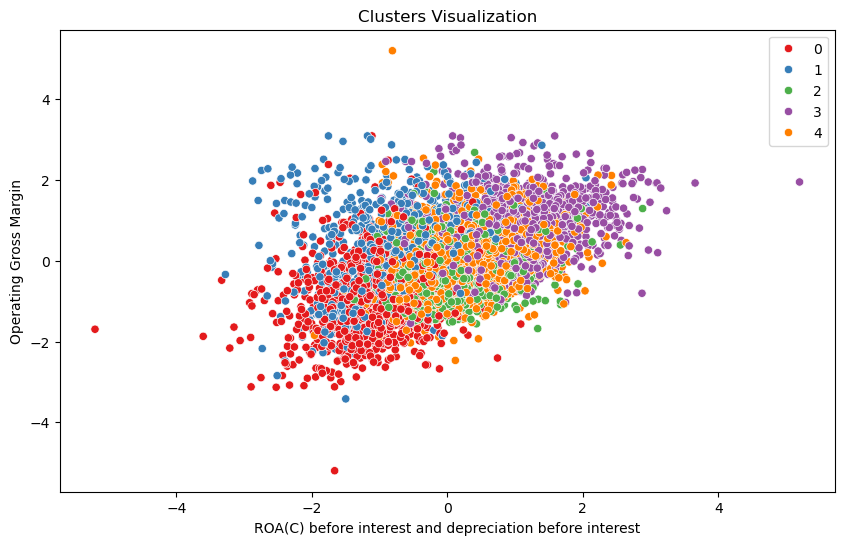

In [92]:
# KMeans clustering (k = 5)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(X_norm_df)
X_norm_df['Cluster'] = cluster_ids
plt.figure(figsize=(10, 6))
sns.countplot(x='Cluster', data=X_norm_df)
plt.title('Cluster Distribution')
plt.show()
# Visualize clusters
plt.figure(figsize=(10, 6))             
sns.scatterplot(x=X_norm_df.iloc[:, 0], y=X_norm_df.iloc[:, 1], hue=cluster_ids, palette='Set1')
plt.title('Clusters Visualization')
plt.show()

In [93]:
X_norm_df.head()

,ROA(C) before interest and depreciation before interest,Operating Gross Margin,Cash flow rate,Net Value Per Share (B),Cash Flow Per Share,Debt ratio %,Fixed Assets Turnover Frequency,Operating profit per person,Working Capital to Total Assets,Cash/Total Assets,Cash/Current Liability,Total expense/Assets,Cash Flow to Total Assets,Cluster
0,-1.168605,-1.573968,-0.436532,-0.325577,-0.574595,0.070964,-1.114032,-1.124689,-0.591218,-0.069704,0.274354,-0.425619,0.738928,0
1,0.574187,-0.034179,-0.065224,0.692715,0.248427,0.071891,-0.506348,0.392302,0.325295,-0.130996,-0.283515,-0.299274,0.407778,4
2,1.251907,0.554790,0.812446,0.783814,1.010382,0.036391,-0.619156,0.809168,0.521002,0.559842,0.618825,-0.319181,1.212510,3
3,-0.497809,-0.412254,-1.798833,-0.297918,-2.727776,1.978041,0.132113,1.014467,0.131558,-0.355639,-0.918414,-1.117056,0.392077,2
4,0.177827,-0.726740,-0.535725,0.482248,-0.418371,0.301855,0.532899,1.005835,-0.015705,1.184060,0.609289,0.634778,-1.108454,2


In [94]:
X_norm_df.columns = X_norm_df.columns.str.strip()

In [95]:
X_norm_df['Bankrupt?'] = train_df['Bankrupt?']
X_norm_df['Index'] = index

In [96]:
X_norm_df

,ROA(C) before interest and depreciation before interest,Operating Gross Margin,Cash flow rate,Net Value Per Share (B),Cash Flow Per Share,Debt ratio %,Fixed Assets Turnover Frequency,Operating profit per person,Working Capital to Total Assets,Cash/Total Assets,Cash/Current Liability,Total expense/Assets,Cash Flow to Total Assets,Cluster,Bankrupt?,Index
0,-1.168605,-1.573968,-0.436532,-0.325577,-0.574595,0.070964,-1.114032,-1.124689,-0.591218,-0.069704,0.274354,-0.425619,0.738928,0,0,0
1,0.574187,-0.034179,-0.065224,0.692715,0.248427,0.071891,-0.506348,0.392302,0.325295,-0.130996,-0.283515,-0.299274,0.407778,4,0,1
2,1.251907,0.554790,0.812446,0.783814,1.010382,0.036391,-0.619156,0.809168,0.521002,0.559842,0.618825,-0.319181,1.212510,3,0,2
3,-0.497809,-0.412254,-1.798833,-0.297918,-2.727776,1.978041,0.132113,1.014467,0.131558,-0.355639,-0.918414,-1.117056,0.392077,2,0,3
4,0.177827,-0.726740,-0.535725,0.482248,-0.418371,0.301855,0.532899,1.005835,-0.015705,1.184060,0.609289,0.634778,-1.108454,2,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5802,0.116941,-1.297989,-0.259765,-0.427976,0.342823,1.361753,-0.824933,0.203379,-1.746558,-0.930034,-1.259094,-0.937054,-0.223996,0,0,5802
5803,0.985923,2.160819,0.607066,0.033880,0.512061,-0.611996,1.710968,0.469603,0.180066,1.571653,1.156042,0.634038,1.221572,3,0,5803
5804,-0.284817,-1.211540,-0.077092,0.417002,0.447305,0.419741,0.814106,0.830234,1.159492,0.460858,0.009082,0.357083,0.272545,4,0,5804
5805,0.248628,2.092602,1.210137,-0.478025,1.256606,1.515605,0.593358,-0.608973,1.125224,1.616497,1.606391,2.215642,2.250804,3,0,5805


In [97]:
X_norm_df.to_csv('processed_data.csv', index=False)

In [98]:
train_df['Cluster'] = cluster_ids
train_df.to_csv('regular_data.csv', index=False)

In [99]:
num_bankrupt = X_norm_df.groupby('Cluster')['Bankrupt?'].sum()
totals = X_norm_df.groupby('Cluster').size()
num_bankrupt

Cluster
0    156
1     11
2     17
3      0
4     14
Name: Bankrupt?, dtype: int64

In [100]:
totals = X_norm_df.groupby('Cluster').size()
totals

Cluster
0    1122
1     842
2     858
3    1143
4    1842
dtype: int64

In [101]:
num_not_bankrupt = totals-num_bankrupt
num_not_bankrupt

Cluster
0     966
1     831
2     841
3    1143
4    1828
dtype: int64

In [102]:
props = num_bankrupt/totals
props

Cluster
0    0.139037
1    0.013064
2    0.019814
3    0.000000
4    0.007600
dtype: float64

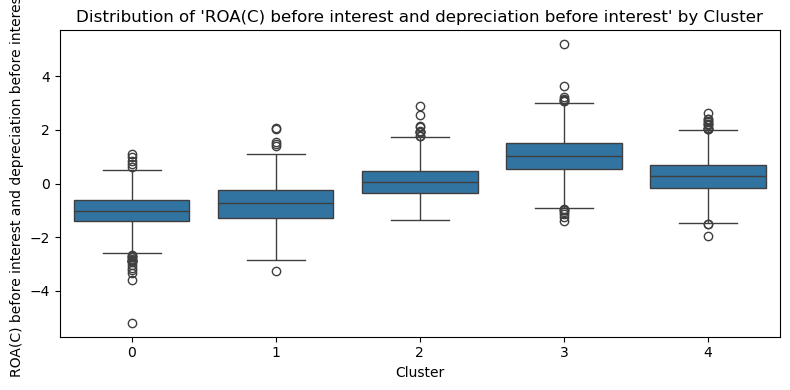

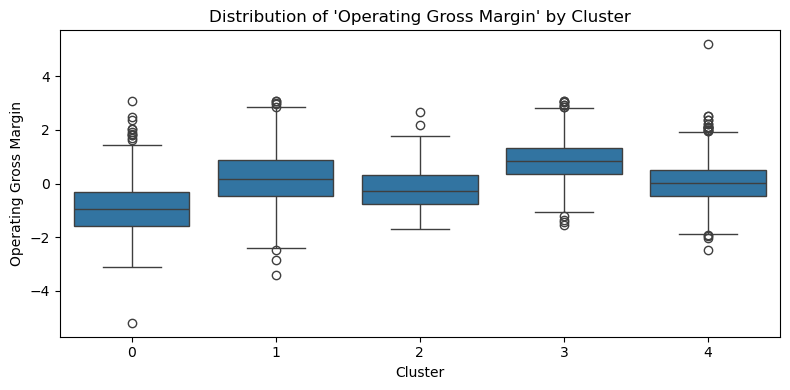

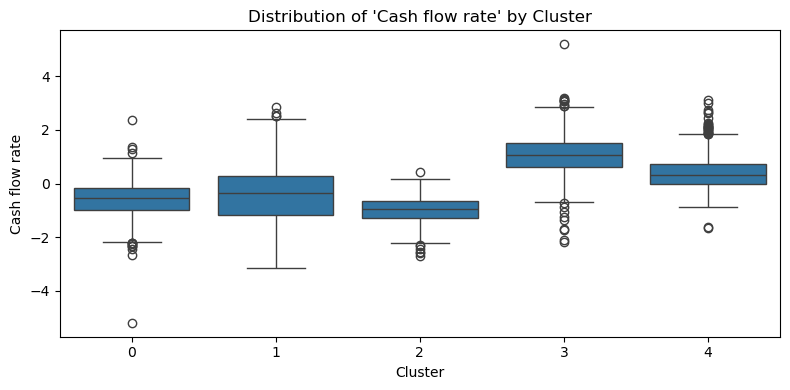

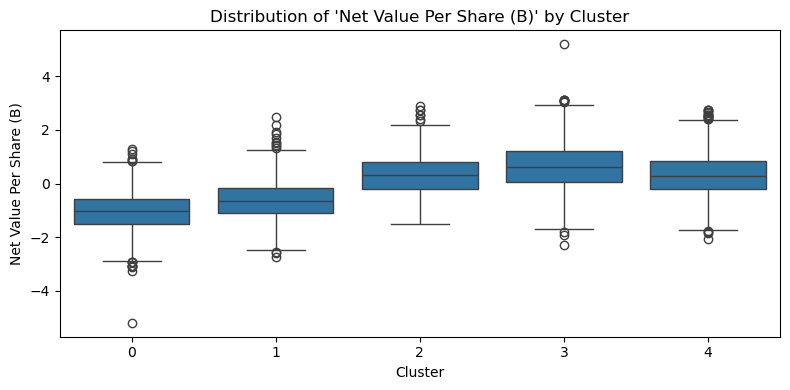

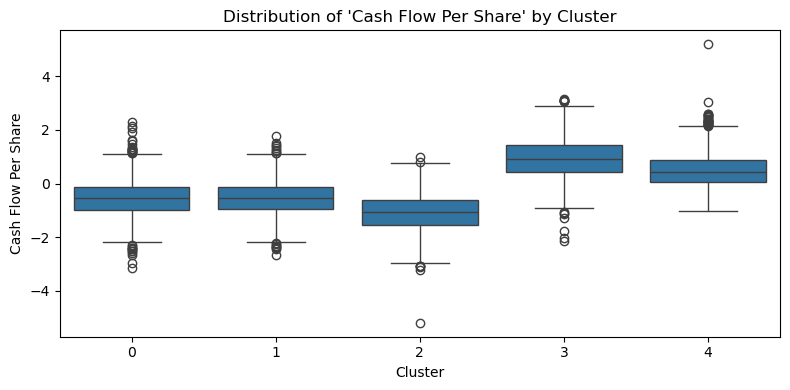

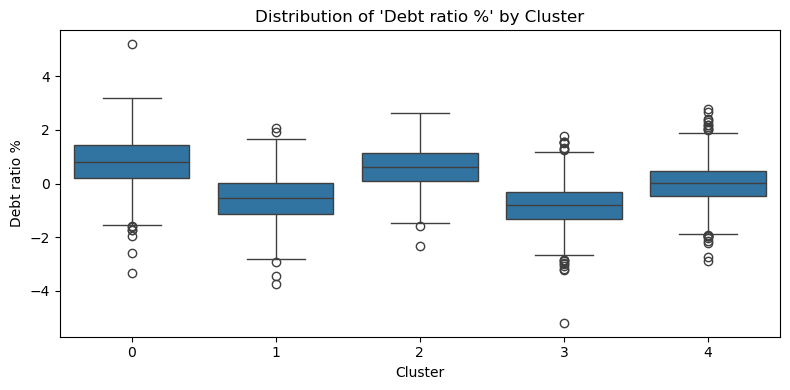

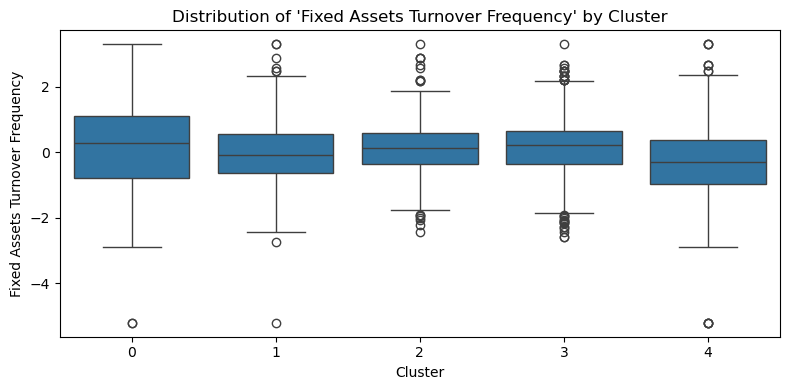

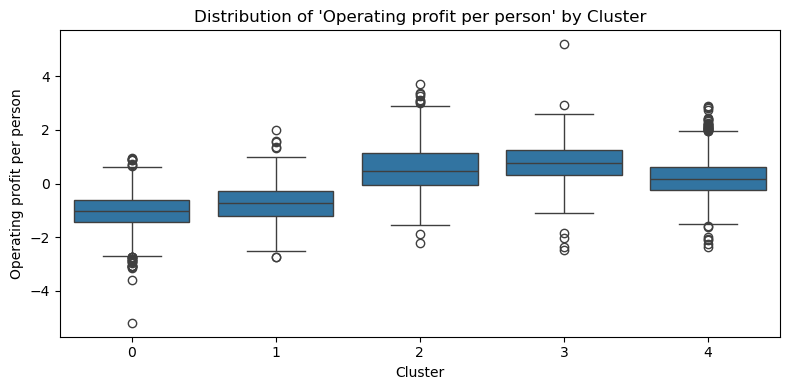

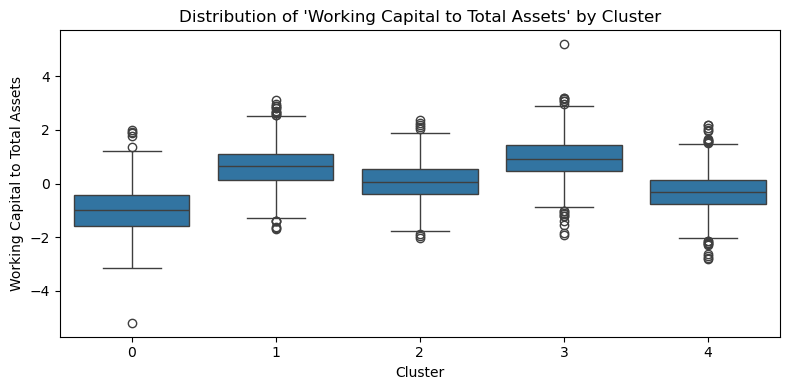

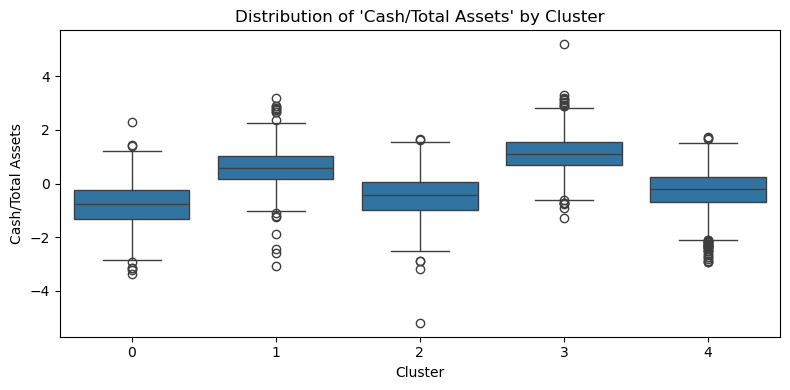

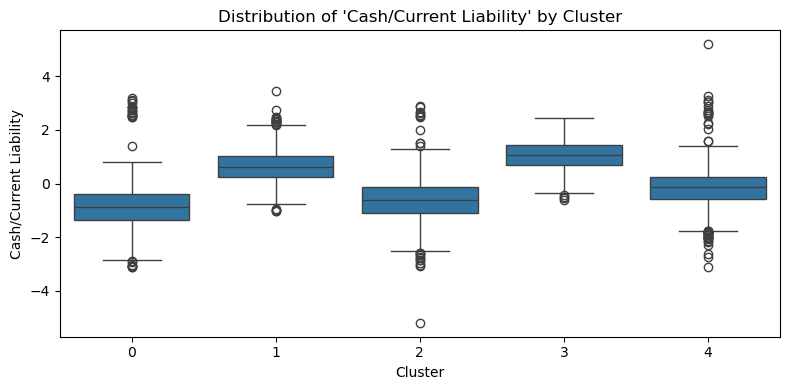

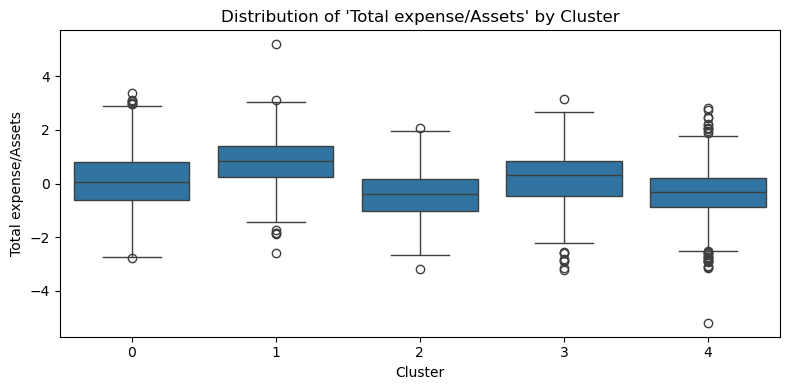

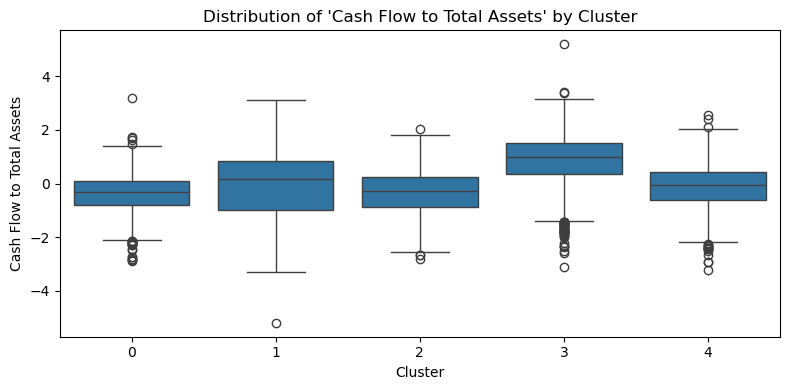

In [103]:
# Top distinctive features across clusters based on inter-cluster variance
key_features = ['Debt ratio %', 'Borrowing dependency', 'Cash/Total Assets', 'Operating profit per person']

# Plot distributions per cluster
for feature in X_norm_df.drop(['Cluster', 'Bankrupt?', 'Index'], axis=1):
    if feature in X_norm_df.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x="Cluster", y=feature, data=X_norm_df)
        plt.title(f"Distribution of '{feature}' by Cluster")
        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️ Warning: Feature '{feature}' not found in dataframe.")


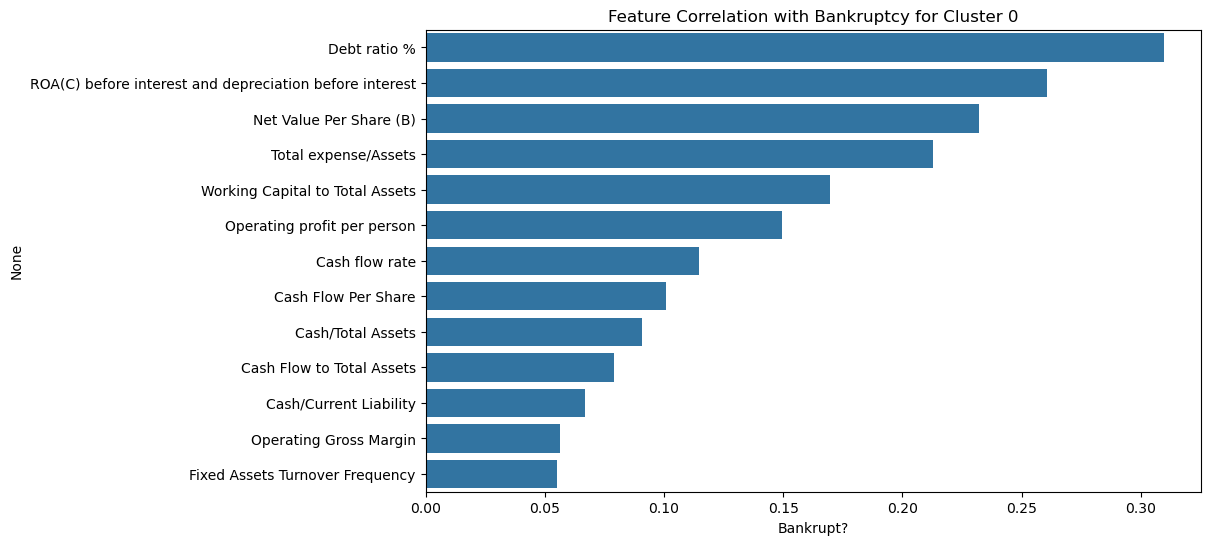

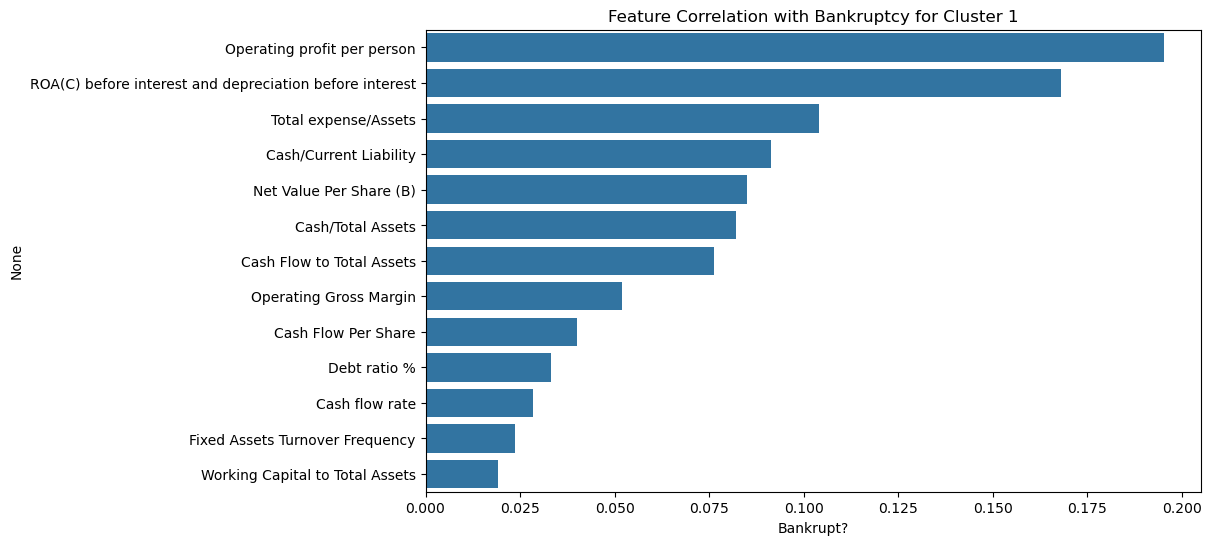

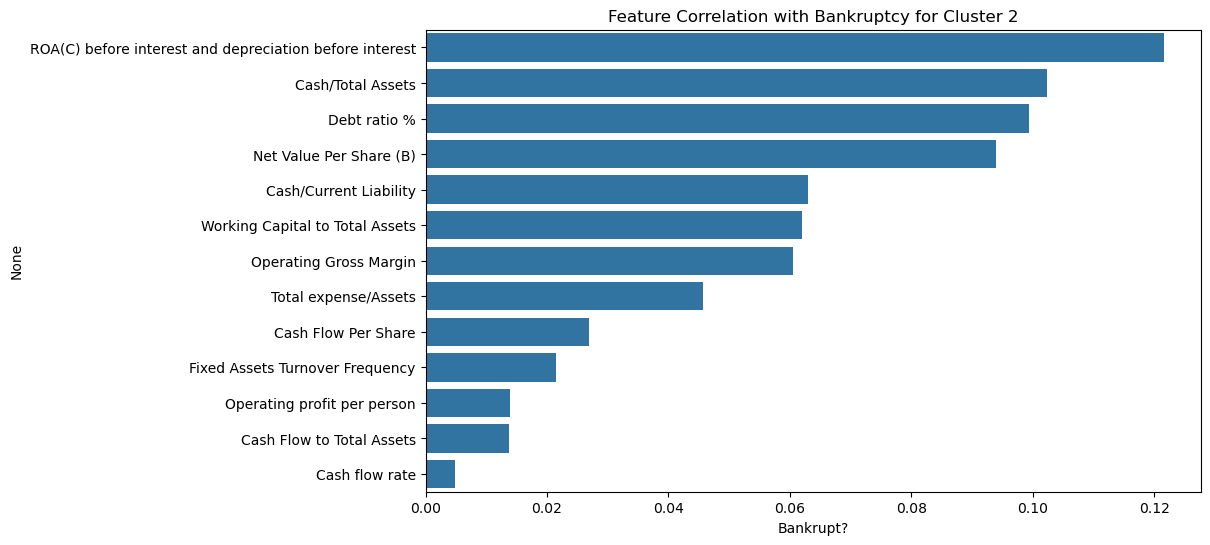

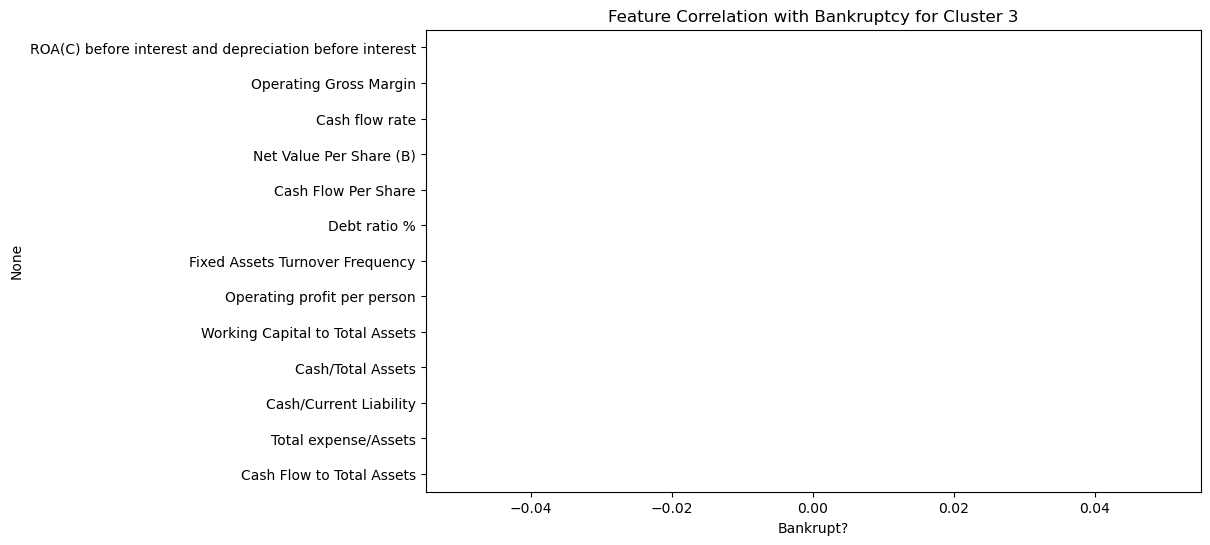

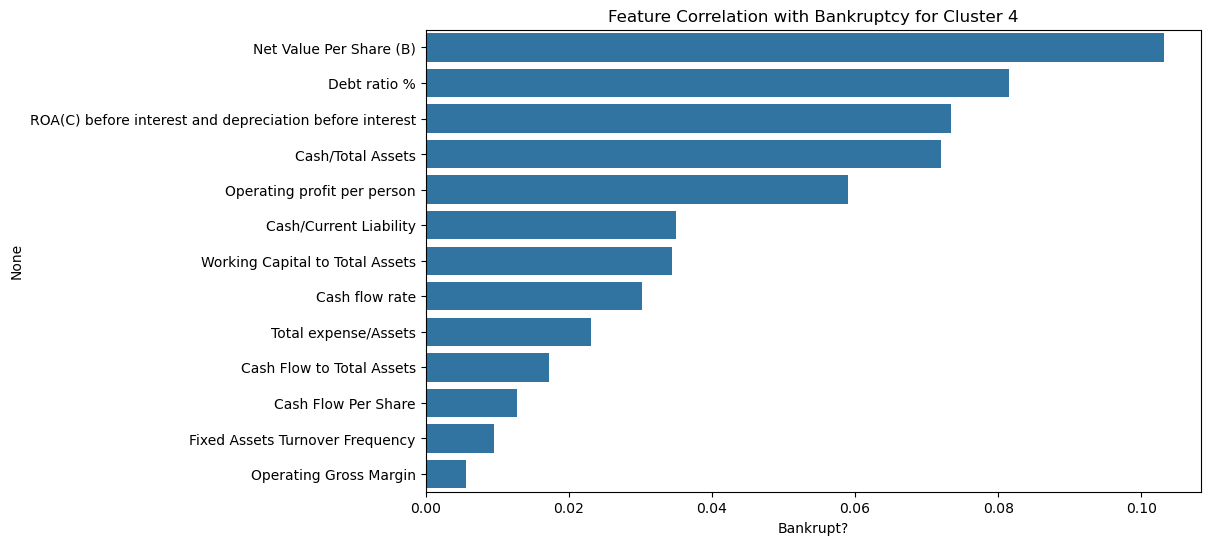

In [104]:
for i in range(5):
    df = X_norm_df[X_norm_df['Cluster'] == i]
    df = df.drop(['Index', 'Cluster'], axis=1)
    corr = df.corr()['Bankrupt?'].drop('Bankrupt?')
    plt.figure(figsize=(10, 6))
    sns.barplot(x=corr.abs().sort_values(ascending=False), y=corr.abs().sort_values(ascending=False).index)
    plt.title(f'Feature Correlation with Bankruptcy for Cluster {i}')
    plt.show()

# 3.3 Cluster Model

In [105]:
# Train classifier to predict clusters
X_train = X_norm_df.drop(['Cluster', 'Bankrupt?', 'Index'], axis=1)
y_train = cluster_ids
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_train)
print("Cluster Model Accuracy")
print('Accuracy:', accuracy_score(y_train, y_pred))
print(classification_report(y_train, y_pred))


import pickle
with open('cluster.pkl', 'wb') as f:
    pickle.dump(clf, f)

Cluster Model Accuracy
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1122
           1       1.00      1.00      1.00       842
           2       1.00      1.00      1.00       858
           3       1.00      1.00      1.00      1143
           4       1.00      1.00      1.00      1842

    accuracy                           1.00      5807
   macro avg       1.00      1.00      1.00      5807
weighted avg       1.00      1.00      1.00      5807



In [106]:
importances = pd.Series(clf.feature_importances_, index=X_norm_df.drop(['Cluster', 'Bankrupt?', 'Index'], axis=1).columns)
print("\nTop features:")
print(importances.sort_values(ascending=False))


Top features:
Cash/Current Liability                                     0.137634
Cash flow rate                                             0.119024
Cash Flow Per Share                                        0.114252
Operating profit per person                                0.099841
ROA(C) before interest and depreciation before interest    0.095159
Cash/Total Assets                                          0.085697
Working Capital to Total Assets                            0.081731
Net Value Per Share (B)                                    0.077234
Debt ratio %                                               0.048980
Operating Gross Margin                                     0.048435
Total expense/Assets                                       0.037888
Cash Flow to Total Assets                                  0.031040
Fixed Assets Turnover Frequency                            0.023086
dtype: float64
